# Feature Selection — Customer Churn

**Purpose:** Narrow down the engineered features to the most  
predictive subset. Too many features can cause overfitting,  
multicollinearity, and slow training.

**Methods used (in order):**
1. Correlation filter — drop highly correlated pairs (> 0.90)
2. Variance Inflation Factor (VIF) — detect multicollinearity
3. Random Forest feature importance — tree-based ranking
4. Recursive Feature Elimination (RFE) — wrapper method
5. Final recommended feature list

**Input:** `data/03_primary/churn_features.csv`

In [2]:
# ── Imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
# ── Load the engineered features ─────────────────────────
df = pd.read_csv('../../data/03_primary/churn_features.csv')

# Define target and features
TARGET = 'agreement_churn'

# Columns to exclude from feature set
# (targets and helper columns that shouldn't be used as features)
exclude_cols = ['agreement_churn', 'customer_churn',
                'total_ret_cases', 'churned_cases']

# Get only numeric feature columns
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols]

print(f"Target: {TARGET}")
print(f"Number of candidate features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Target: agreement_churn
Number of candidate features: 19
Features: ['avg_van', 'total_van', 'num_contracts', 'num_machines', 'total_repair_cases', 'total_overdue_services', 'has_any_overdue', 'avg_repair_ratio', 'any_van_changed', 'typical_creation_month', 'total_agreements', 'total_annual_value', 'avg_agreement_value', 'avg_agreement_duration', 'num_lines_of_business', 'num_machine_types', 'total_bob_value', 'avg_product_bob', 'company_size_encoded']


In [4]:
# ── Prepare feature matrix (drop rows with any NaN) ──────
# WHY: Most sklearn methods cannot handle NaN values.
# We drop NaN rows here for feature selection only;
# in modelling we may impute instead.

work_df = df[feature_cols + [TARGET]].dropna()

X = work_df[feature_cols]
y = work_df[TARGET]

print(f"Working dataset: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Target balance: {y.value_counts().to_dict()}")

Working dataset: 2689 rows × 19 features
Target balance: {0: 2066, 1: 623}


---
## Method 1 — Correlation Filter

**WHY:** If two features are highly correlated (> 0.90), they  
carry nearly the same information. Keeping both adds noise  
and causes multicollinearity. We drop one from each pair.

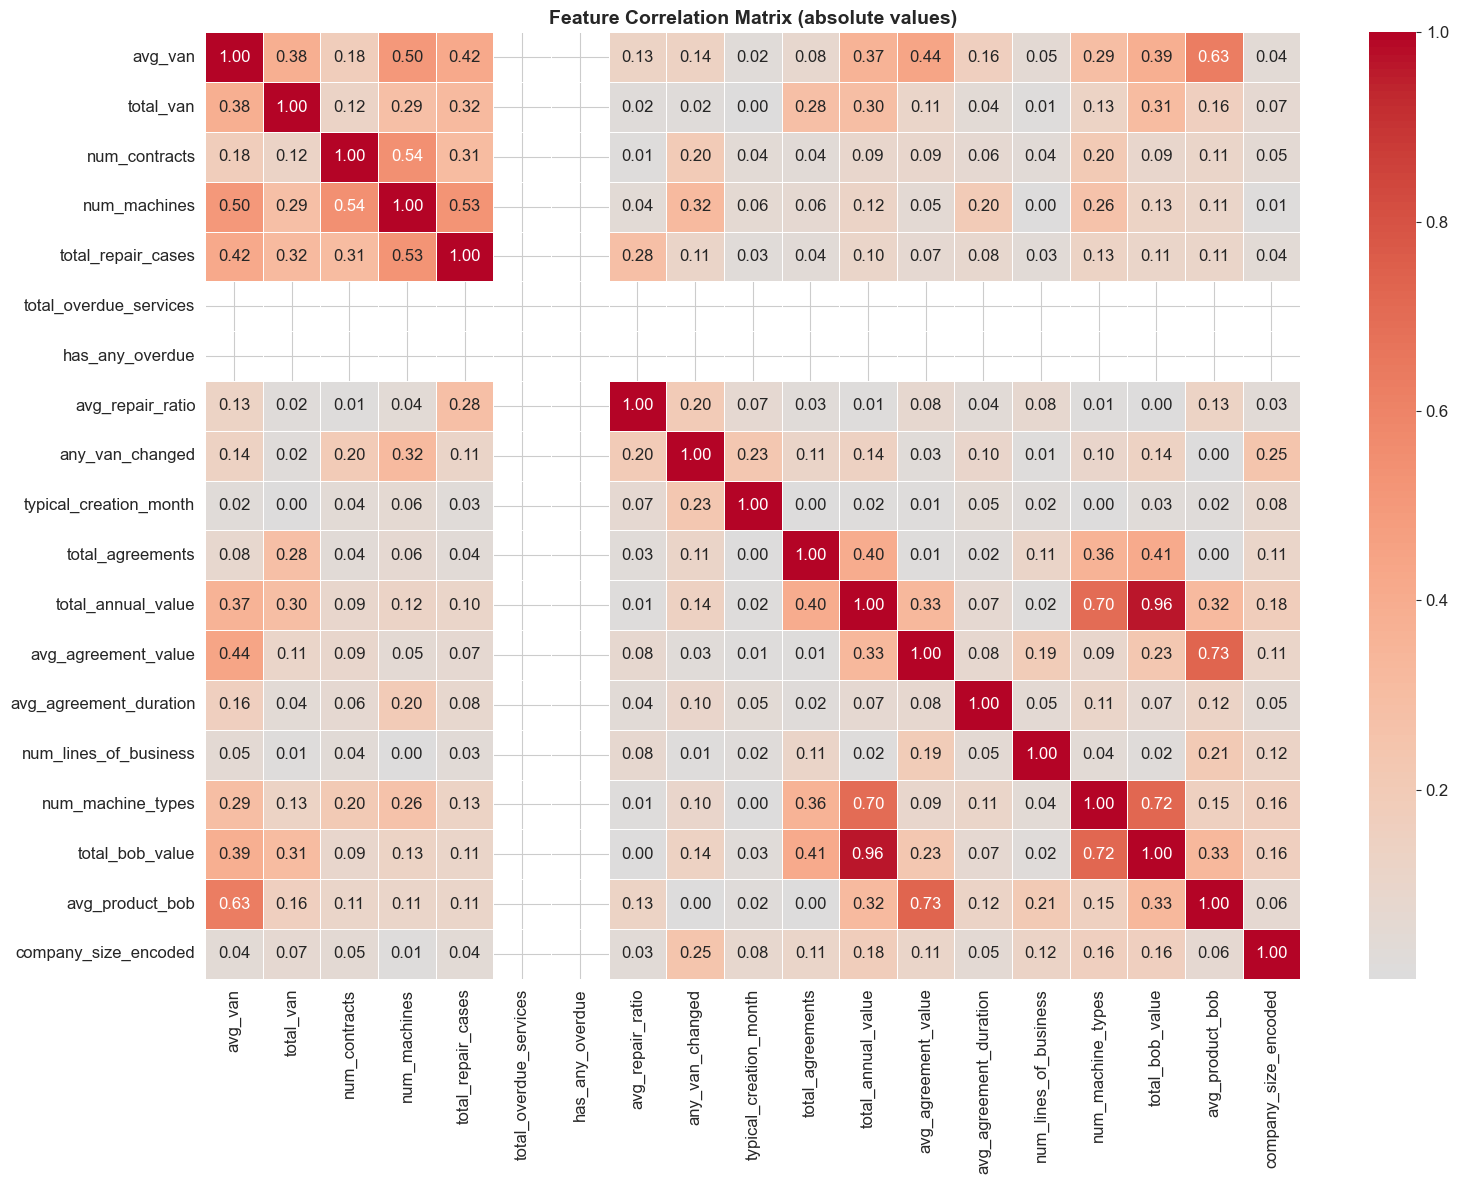

In [5]:
# ── Correlation heatmap ──────────────────────────────────
corr_matrix = X.corr().abs()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix (absolute values)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ── Identify and drop highly correlated features ─────────
# WHY: We use the upper triangle of the corr matrix to find
# pairs with correlation > 0.90.  For each pair, we drop the
# feature that has lower correlation with the target.

CORR_THRESHOLD = 0.90

# Get the upper triangle (exclude diagonal and below)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns to drop
high_corr_pairs = []
to_drop_corr = set()

for col in upper_tri.columns:
    for row in upper_tri.index:
        if upper_tri.loc[row, col] > CORR_THRESHOLD:
            high_corr_pairs.append((row, col, round(upper_tri.loc[row, col], 3)))
            # Drop the one with lower correlation to target
            corr_with_target_row = abs(X[row].corr(y))
            corr_with_target_col = abs(X[col].corr(y))
            if corr_with_target_row < corr_with_target_col:
                to_drop_corr.add(row)
            else:
                to_drop_corr.add(col)

print(f"Highly correlated pairs (>{CORR_THRESHOLD}):")
for pair in high_corr_pairs:
    print(f"  {pair[0]}  ↔  {pair[1]}  (r = {pair[2]})")

print(f"\nFeatures to drop: {to_drop_corr}")

# Drop them
remaining_cols = [c for c in feature_cols if c not in to_drop_corr]
print(f"\nFeatures remaining after correlation filter: {len(remaining_cols)}")

Highly correlated pairs (>0.9):
  total_annual_value  ↔  total_bob_value  (r = 0.963)

Features to drop: {'total_annual_value'}

Features remaining after correlation filter: 18


---
## Method 2 — Variance Inflation Factor (VIF)

**WHY:** VIF measures how much a feature can be predicted by  
other features. VIF > 10 means severe multicollinearity —  
drop those features.

In [7]:
# ── Calculate VIF for remaining features ──────────────────
# WHY: Even after the correlation filter, some features may
# still be linearly dependent on COMBINATIONS of others.

X_vif = work_df[remaining_cols].dropna()

# Scale features first — VIF is sensitive to scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_vif),
    columns=X_vif.columns
)

# Calculate VIF for each feature
vif_data = pd.DataFrame({
    'Feature': X_scaled.columns,
    'VIF': [variance_inflation_factor(X_scaled.values, i)
            for i in range(X_scaled.shape[1])]
})
vif_data = vif_data.sort_values('VIF', ascending=False)

print("VIF values (higher = more multicollinear):")
print(vif_data.to_string(index=False))

# Flag features with VIF > 10
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\nFeatures with VIF > 10: {high_vif}")

VIF values (higher = more multicollinear):
               Feature      VIF
       avg_product_bob 3.260593
               avg_van 3.024958
       total_bob_value 2.797106
          num_machines 2.654317
     num_machine_types 2.482777
   avg_agreement_value 2.155077
    total_repair_cases 1.716723
         num_contracts 1.560934
             total_van 1.425173
       any_van_changed 1.364327
      total_agreements 1.331720
      avg_repair_ratio 1.196067
  company_size_encoded 1.124766
 num_lines_of_business 1.103471
avg_agreement_duration 1.072064
typical_creation_month 1.063570
total_overdue_services      NaN
       has_any_overdue      NaN

Features with VIF > 10: []


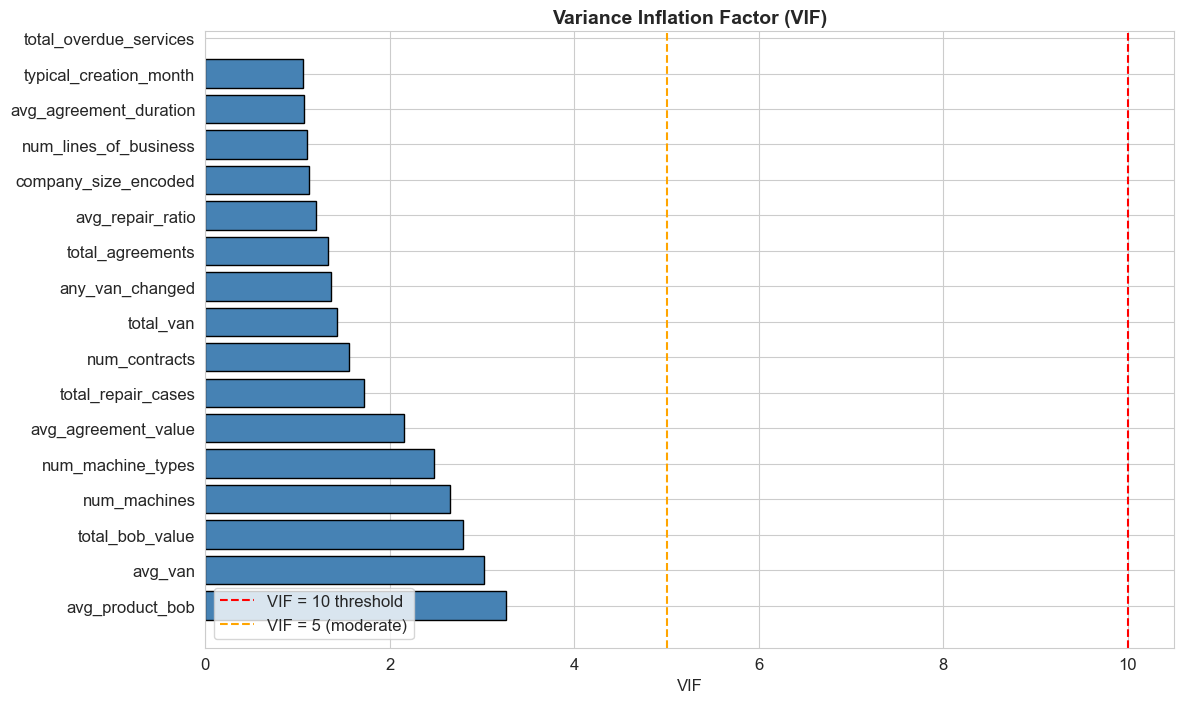

In [8]:
# ── Visualise VIF ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, max(6, len(vif_data) * 0.4)))
ax.barh(vif_data['Feature'], vif_data['VIF'],
        color='steelblue', edgecolor='black')
ax.axvline(x=10, color='red', linestyle='--', label='VIF = 10 threshold')
ax.axvline(x=5, color='orange', linestyle='--', label='VIF = 5 (moderate)')
ax.set_title('Variance Inflation Factor (VIF)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── Remove high-VIF features ─────────────────────────────
# WHY: High VIF means the coefficient estimates will be
# unstable in linear models (logistic regression, etc.)

after_vif_cols = [c for c in remaining_cols if c not in high_vif]
print(f"Features remaining after VIF filter: {len(after_vif_cols)}")
print(after_vif_cols)

Features remaining after VIF filter: 18
['avg_van', 'total_van', 'num_contracts', 'num_machines', 'total_repair_cases', 'total_overdue_services', 'has_any_overdue', 'avg_repair_ratio', 'any_van_changed', 'typical_creation_month', 'total_agreements', 'avg_agreement_value', 'avg_agreement_duration', 'num_lines_of_business', 'num_machine_types', 'total_bob_value', 'avg_product_bob', 'company_size_encoded']


---
## Method 3 — Random Forest Feature Importance

**WHY:** Tree-based models measure how much each feature  
reduces impurity (Gini). This gives a quick, non-linear  
ranking of feature usefulness — even catches interactions  
that correlation misses.

In [10]:
# ── Fit a quick Random Forest ─────────────────────────────
# WHY: We're not tuning for accuracy here — just using it
# as a feature importance estimator.

# Use all numeric features (including ones we might have
# dropped from VIF) to get a complete picture.
X_rf = work_df[feature_cols].fillna(0)
y_rf = work_df[TARGET]

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,         # limit depth to avoid overfitting
    random_state=42,
    n_jobs=-1
)
rf.fit(X_rf, y_rf)

# Get feature importances
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Random Forest Feature Importance (top 20):")
print(rf_importance.head(20).to_string(index=False))

Random Forest Feature Importance (top 20):
               Feature  Importance
             total_van    0.122749
               avg_van    0.118151
          num_machines    0.109408
       total_bob_value    0.089212
    total_annual_value    0.080520
       avg_product_bob    0.075655
   avg_agreement_value    0.065762
avg_agreement_duration    0.058976
typical_creation_month    0.048351
      total_agreements    0.046134
         num_contracts    0.045019
     num_machine_types    0.035731
  company_size_encoded    0.027412
    total_repair_cases    0.026344
       any_van_changed    0.021627
      avg_repair_ratio    0.017106
 num_lines_of_business    0.011842
total_overdue_services    0.000000
       has_any_overdue    0.000000


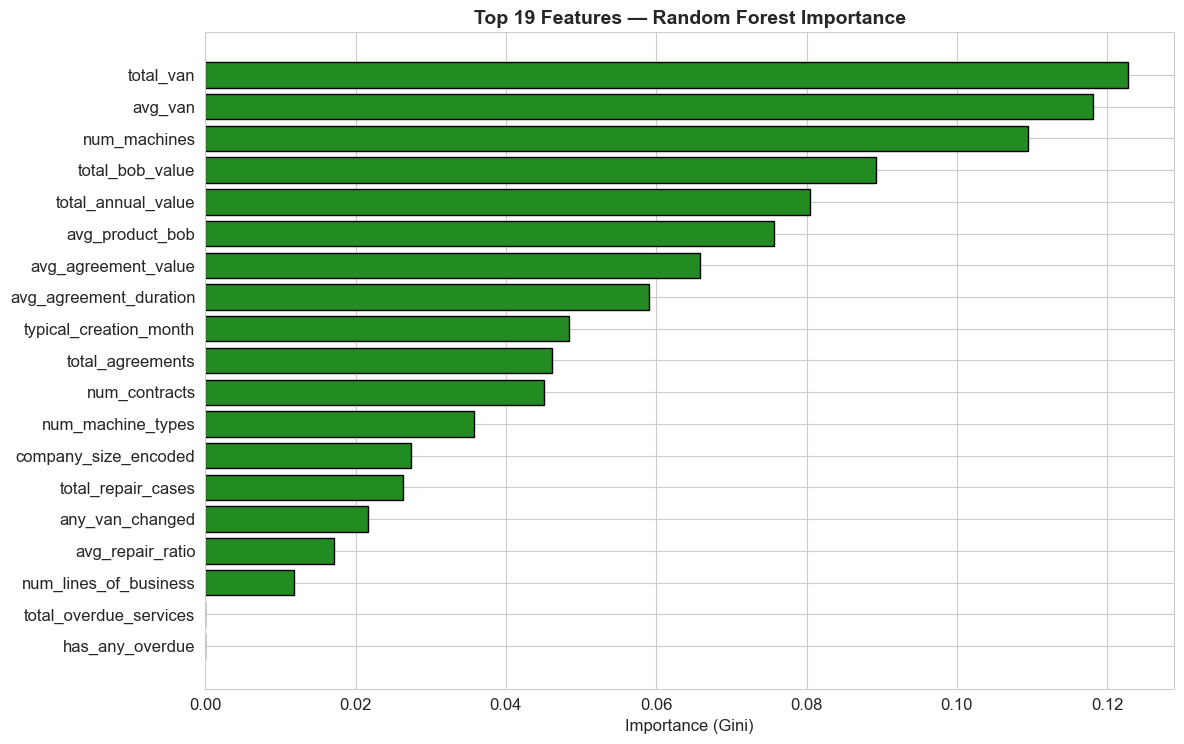

In [11]:
# ── Visualise RF importance ──────────────────────────────
top_n = min(20, len(rf_importance))

fig, ax = plt.subplots(figsize=(12, max(6, top_n * 0.4)))
rf_top = rf_importance.head(top_n).sort_values('Importance')
ax.barh(rf_top['Feature'], rf_top['Importance'],
        color='forestgreen', edgecolor='black')
ax.set_title(f'Top {top_n} Features — Random Forest Importance',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

---
## Method 4 — Recursive Feature Elimination (RFE)

**WHY:** RFE trains a model, removes the least important  
feature, retrains, and repeats. This 'wrapper' approach  
captures feature interactions better than simple filters.  
We use Logistic Regression as the estimator — it's fast  
and interpretable.

In [12]:
# ── Run RFE with Logistic Regression ─────────────────────
# WHY: We select the top ~50 % of features as a starting point.
# You can adjust n_features_to_select based on the RF results.

# Scale features for Logistic Regression
X_rfe = work_df[feature_cols].fillna(0)
scaler_rfe = StandardScaler()
X_rfe_scaled = scaler_rfe.fit_transform(X_rfe)

n_select = max(5, len(feature_cols) // 2)  # select top half, minimum 5

lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=n_select, step=1)
rfe.fit(X_rfe_scaled, y_rf)

# Results
rfe_results = pd.DataFrame({
    'Feature': feature_cols,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print(f"RFE selected {n_select} features:")
selected_by_rfe = rfe_results[rfe_results['Selected']]['Feature'].tolist()
print(selected_by_rfe)

print("\nFull RFE ranking:")
print(rfe_results.to_string(index=False))

RFE selected 9 features:
['avg_van', 'total_van', 'num_machines', 'total_repair_cases', 'avg_repair_ratio', 'avg_agreement_duration', 'total_agreements', 'any_van_changed', 'avg_product_bob']

Full RFE ranking:
               Feature  Selected  Ranking
               avg_van      True        1
             total_van      True        1
          num_machines      True        1
    total_repair_cases      True        1
      avg_repair_ratio      True        1
avg_agreement_duration      True        1
      total_agreements      True        1
       any_van_changed      True        1
       avg_product_bob      True        1
    total_annual_value     False        2
       total_bob_value     False        3
   avg_agreement_value     False        4
typical_creation_month     False        5
  company_size_encoded     False        6
         num_contracts     False        7
 num_lines_of_business     False        8
     num_machine_types     False        9
total_overdue_services     False 

---
## Final Consolidated Feature Recommendation

In [13]:
# ── Consolidate results from all methods ─────────────────
# WHY: No single method is perfect. By combining results
# from correlation filter, VIF, RF importance, and RFE,
# we get a robust final feature set.

# Top features by RF (top half)
top_rf = set(rf_importance.head(n_select)['Feature'].tolist())

# Features selected by RFE
top_rfe = set(selected_by_rfe)

# Features that survived VIF and correlation filter
survived_filter = set(after_vif_cols)

# Build summary table
summary_rows = []
for feat in feature_cols:
    summary_rows.append({
        'Feature': feat,
        'Passed Corr Filter': '✓' if feat not in to_drop_corr else '✗',
        'Passed VIF (<10)': '✓' if feat not in high_vif else '✗',
        'RF Top Half': '✓' if feat in top_rf else '',
        'RFE Selected': '✓' if feat in top_rfe else '',
        'RF Importance': round(rf_importance[rf_importance['Feature'] == feat]['Importance'].values[0], 4)
            if feat in rf_importance['Feature'].values else 0
    })

summary_df = pd.DataFrame(summary_rows).sort_values('RF Importance', ascending=False)

print("=" * 90)
print("FEATURE SELECTION SUMMARY")
print("=" * 90)
summary_df

FEATURE SELECTION SUMMARY


,Feature,Passed Corr Filter,Passed VIF (<10),RF Top Half,RFE Selected,RF Importance
1,total_van,✓,✓,✓,✓,0.1227
0,avg_van,✓,✓,✓,✓,0.1182
3,num_machines,✓,✓,✓,✓,0.1094
16,total_bob_value,✓,✓,✓,,0.0892
11,total_annual_value,✗,✓,✓,,0.0805
17,avg_product_bob,✓,✓,✓,✓,0.0757
12,avg_agreement_value,✓,✓,✓,,0.0658
13,avg_agreement_duration,✓,✓,✓,✓,0.0590
9,typical_creation_month,✓,✓,✓,,0.0484
10,total_agreements,✓,✓,,✓,0.0461


In [14]:
# ── Final recommended feature list ───────────────────────
# WHY: We recommend features that are selected by at least
# TWO of the four methods.  This consensus approach is more
# reliable than any single method.

def count_selections(row):
    """Count how many methods selected this feature."""
    count = 0
    if row['Passed Corr Filter'] == '✓': count += 1
    if row['Passed VIF (<10)'] == '✓': count += 1
    if row['RF Top Half'] == '✓': count += 1
    if row['RFE Selected'] == '✓': count += 1
    return count

summary_df['Methods Selected'] = summary_df.apply(count_selections, axis=1)

# Keep features selected by at least 2 methods
recommended = summary_df[summary_df['Methods Selected'] >= 2]
recommended_features = recommended['Feature'].tolist()

print(f"\nFinal recommended features ({len(recommended_features)}):")
for feat in recommended_features:
    print(f"  • {feat}")

print("\nDetailed breakdown:")
recommended.sort_values('Methods Selected', ascending=False)


Final recommended features (19):
  • total_van
  • avg_van
  • num_machines
  • total_bob_value
  • total_annual_value
  • avg_product_bob
  • avg_agreement_value
  • avg_agreement_duration
  • typical_creation_month
  • total_agreements
  • num_contracts
  • num_machine_types
  • company_size_encoded
  • total_repair_cases
  • any_van_changed
  • avg_repair_ratio
  • num_lines_of_business
  • total_overdue_services
  • has_any_overdue

Detailed breakdown:


,Feature,Passed Corr Filter,Passed VIF (<10),RF Top Half,RFE Selected,RF Importance,Methods Selected
1,total_van,✓,✓,✓,✓,0.1227,4
0,avg_van,✓,✓,✓,✓,0.1182,4
3,num_machines,✓,✓,✓,✓,0.1094,4
17,avg_product_bob,✓,✓,✓,✓,0.0757,4
13,avg_agreement_duration,✓,✓,✓,✓,0.0590,4
12,avg_agreement_value,✓,✓,✓,,0.0658,3
16,total_bob_value,✓,✓,✓,,0.0892,3
10,total_agreements,✓,✓,,✓,0.0461,3
9,typical_creation_month,✓,✓,✓,,0.0484,3
4,total_repair_cases,✓,✓,,✓,0.0263,3


In [15]:
# ── Save the recommended features list ───────────────────
# WHY: The modelling notebook can read this list directly
# instead of re-running feature selection.

pd.DataFrame({'feature': recommended_features}).to_csv(
    '../../data/03_primary/selected_features.csv', index=False
)

print(f"Saved {len(recommended_features)} selected features to")
print("data/03_primary/selected_features.csv")

Saved 19 selected features to
data/03_primary/selected_features.csv


---
## Summary

| Step | Method | What it filters out |
|---|---|---|
| 1 | Correlation > 0.90 | Redundant feature pairs |
| 2 | VIF > 10 | Multicollinear features |
| 3 | Random Forest Importance | Low-importance features |
| 4 | RFE (Logistic Regression) | Features that don't improve the model |

The final recommended list contains features that passed **at least 2** of the 4 checks.  
Use this list in the modelling notebook.